[2026-08-04 05:52:53] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-08-04 05:52:55] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-08-04 05:52:55] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-08-04 05:52:55] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2024-01-02 至 2024-12-31
[2026-08-04 05:52:55] [info     ] ========== 数据检查 ==========
[2026-08-04 05:52:55] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg_ttm', 'roa_avg_ttm', 'gross_profit_rate_ttm', 'net_profit_rate_ttm', 'debt_to_asset_lf', 'current_ratio_lf', 'netflow_amount_main', 'netflow_amount_rate_main', 'net_act

时段,IC
2024-01-15~2024-02-08,-0.0151
2024-09-24~2024-10-08,0.0557

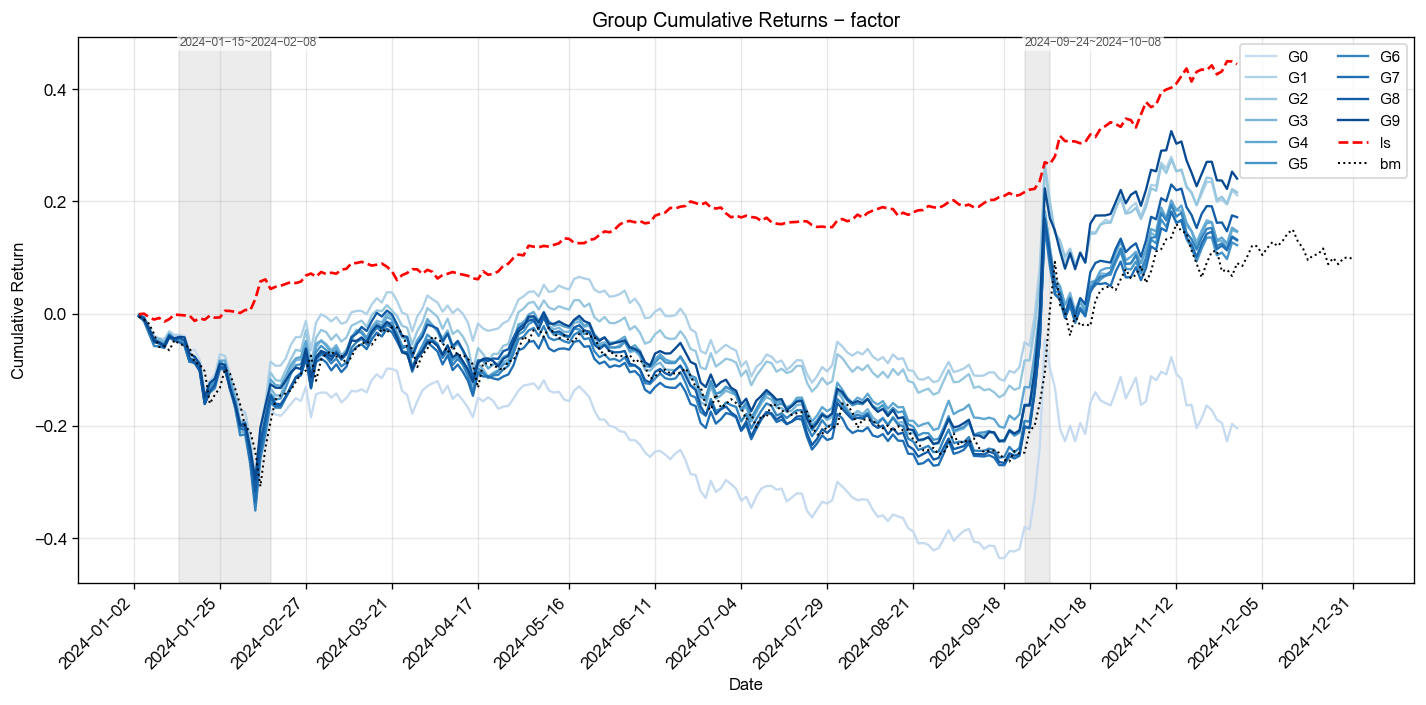
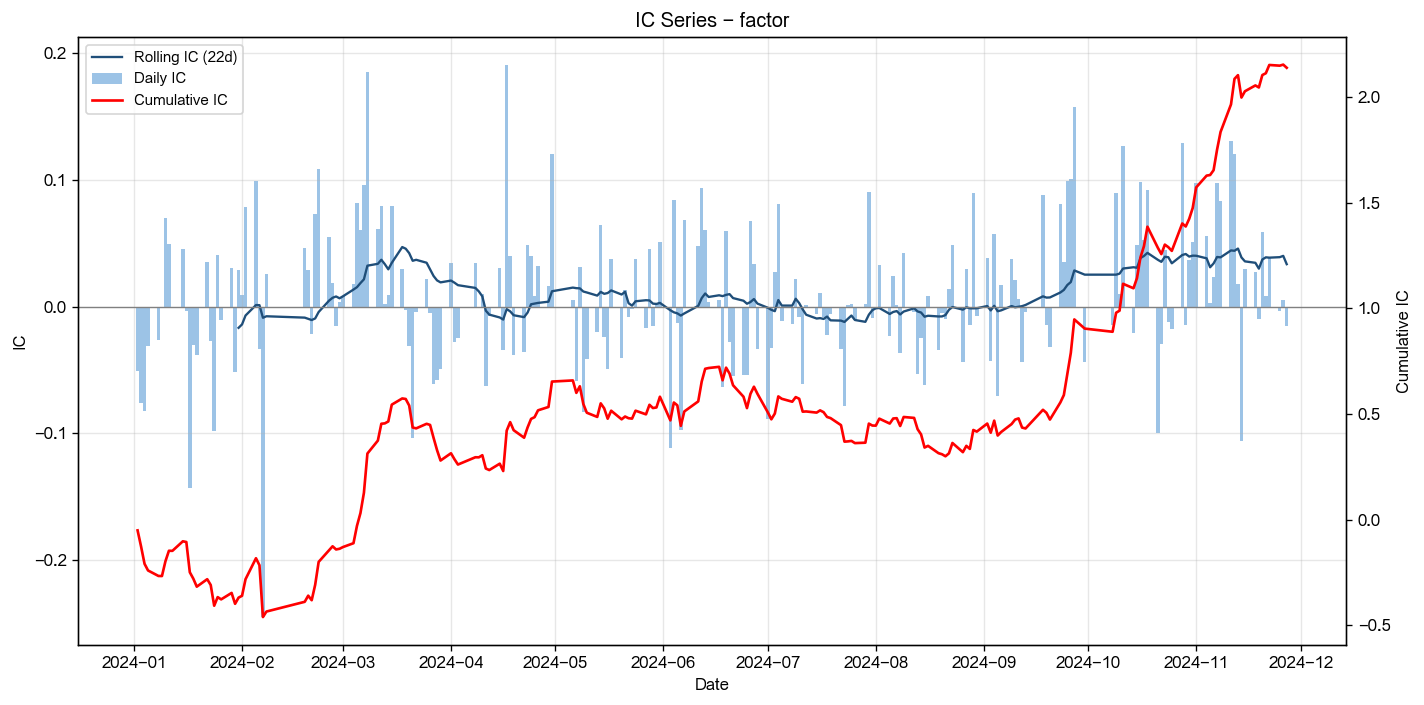
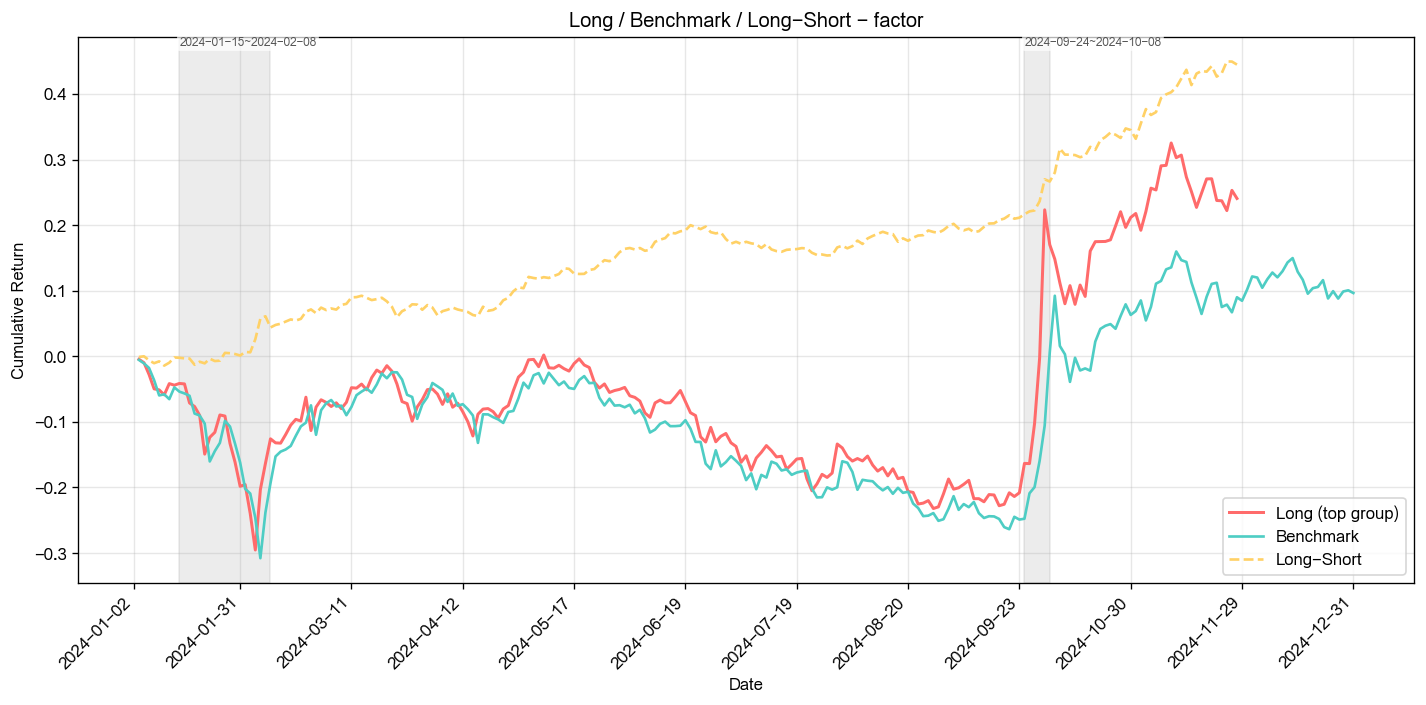
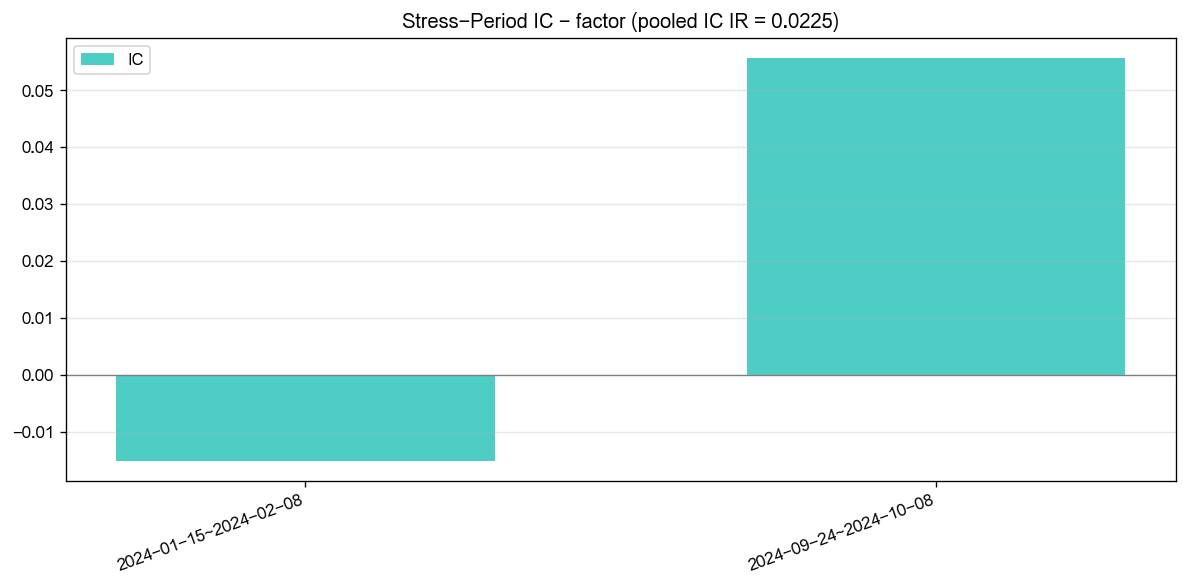
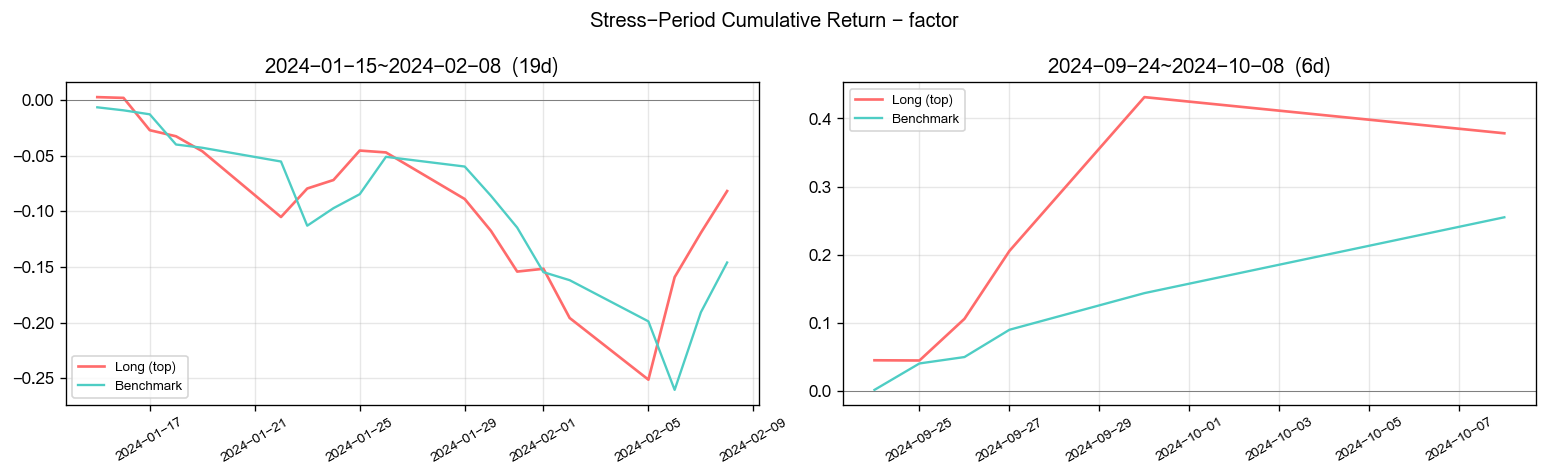

[2026-08-04 05:53:11] [info     ] ========== 因子池回归 ==========
[2026-08-04 05:53:12] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1206 rows=297953 start_date=2024-01-02
[2026-08-04 05:53:12] [info     ] 获取收益率数据, 耗时: 0.4653 秒
[2026-08-04 05:53:12] [info     ] 滚动 Elastic Net 拟合, 耗时: 0.5346 秒
[2026-08-04 05:53:12] [info     ] 统计 回归结果, 耗时: 0.006 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,rsi_12,1.9562,0.0436,0.0223,1.0000
2,amount,1.6681,0.0179,0.0107,0.9000
3,gross_profit_rate_ttm,1.5089,0.0069,0.0045,1.0000
4,netflow_amount_main,1.4915,0.0248,0.0166,1.0000
5,factor,1.4824,0.0154,0.0104,1.0000
6,netflow_amount_rate_main,1.4769,0.0103,0.0070,1.0000
7,net_profit_rate_ttm,1.4345,0.0040,0.0028,0.8000
8,pb,1.4179,0.0097,0.0069,0.9000
9,bias_20,1.3765,0.0282,0.0205,0.9000
10,cci_14,1.3571,0.0341,0.0251,1.0000

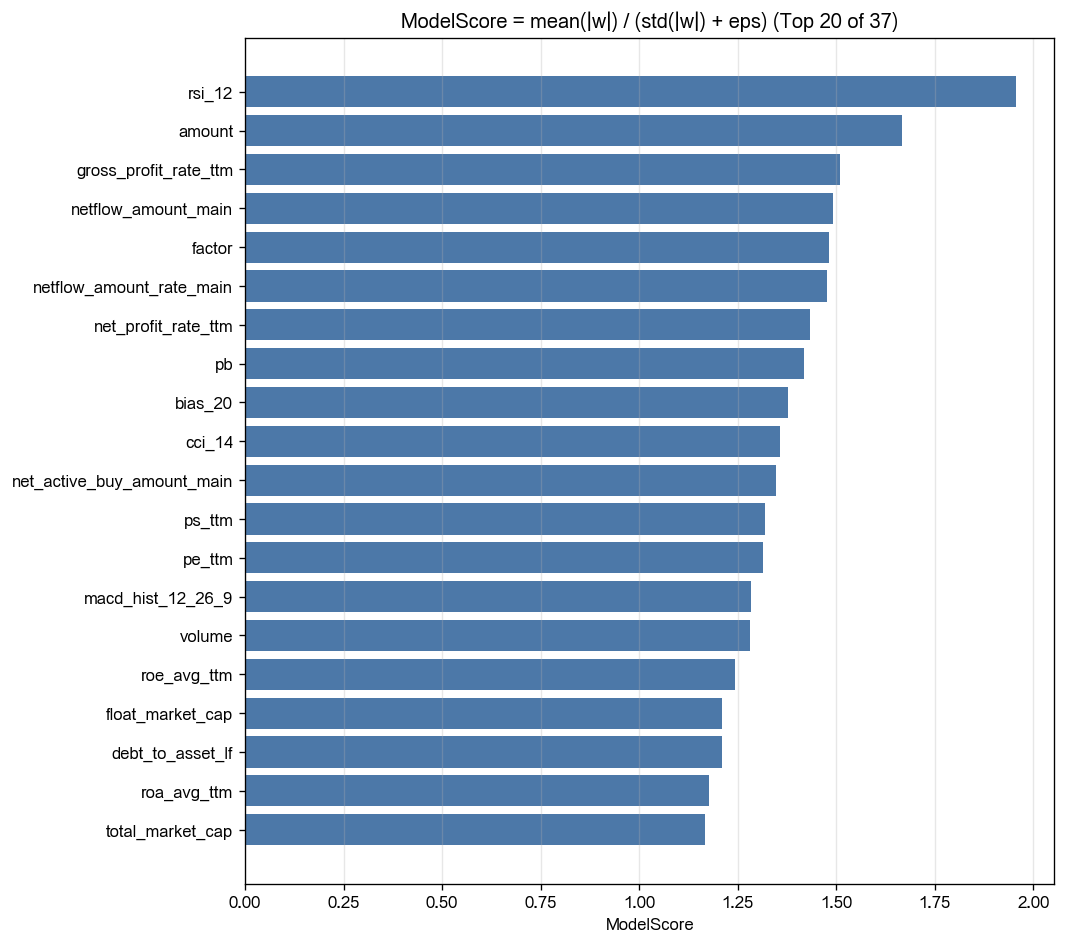
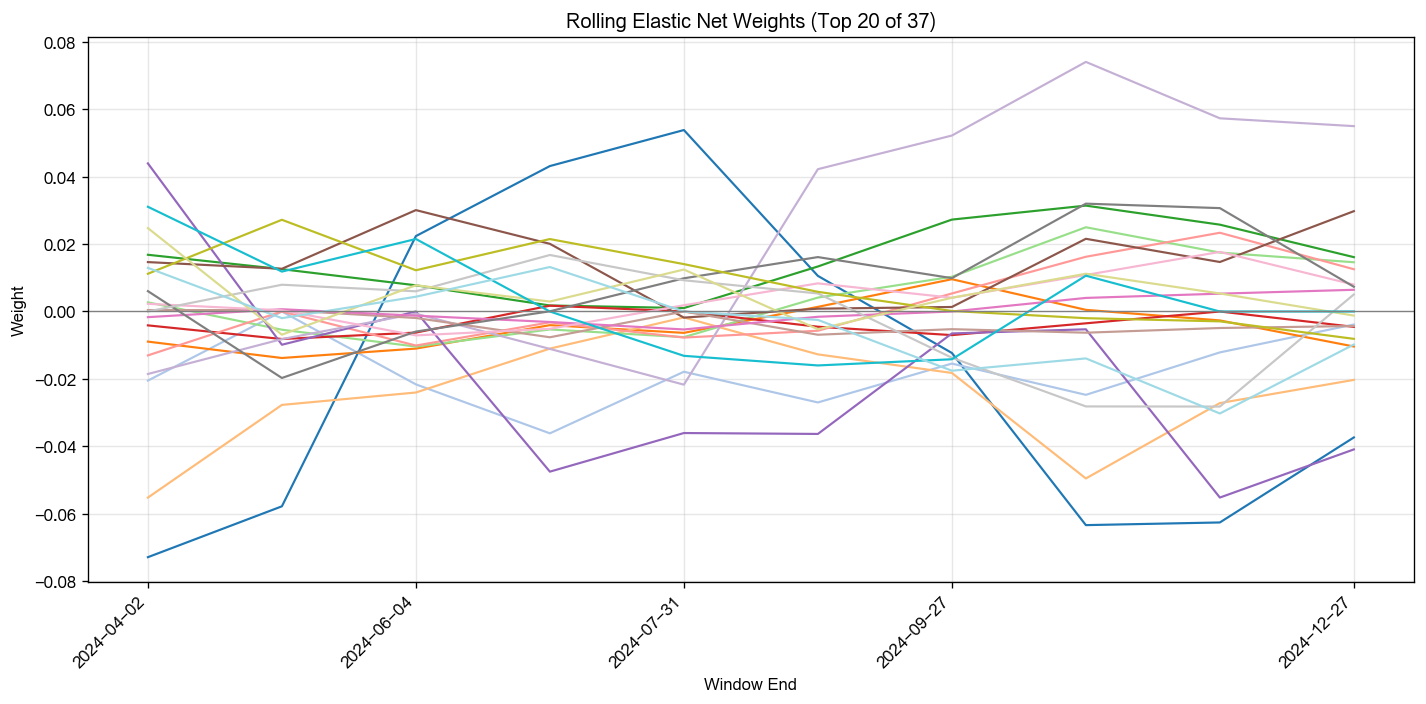
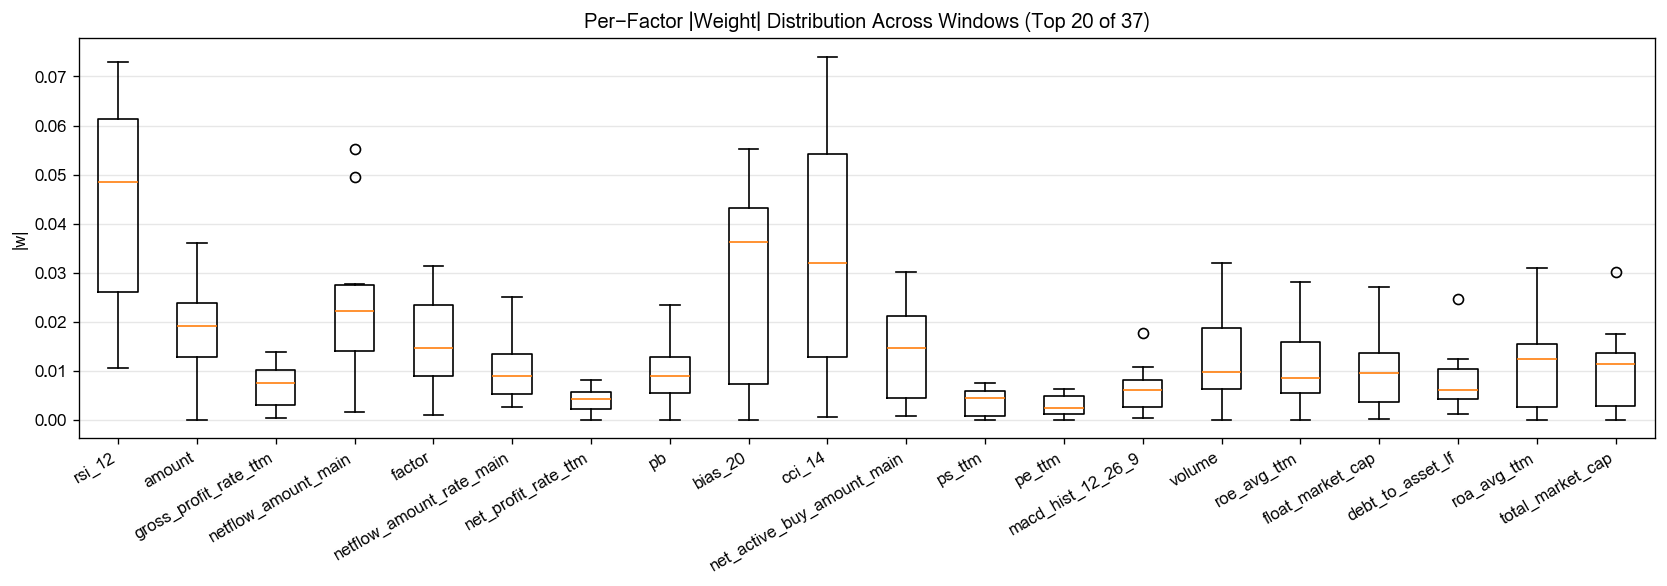
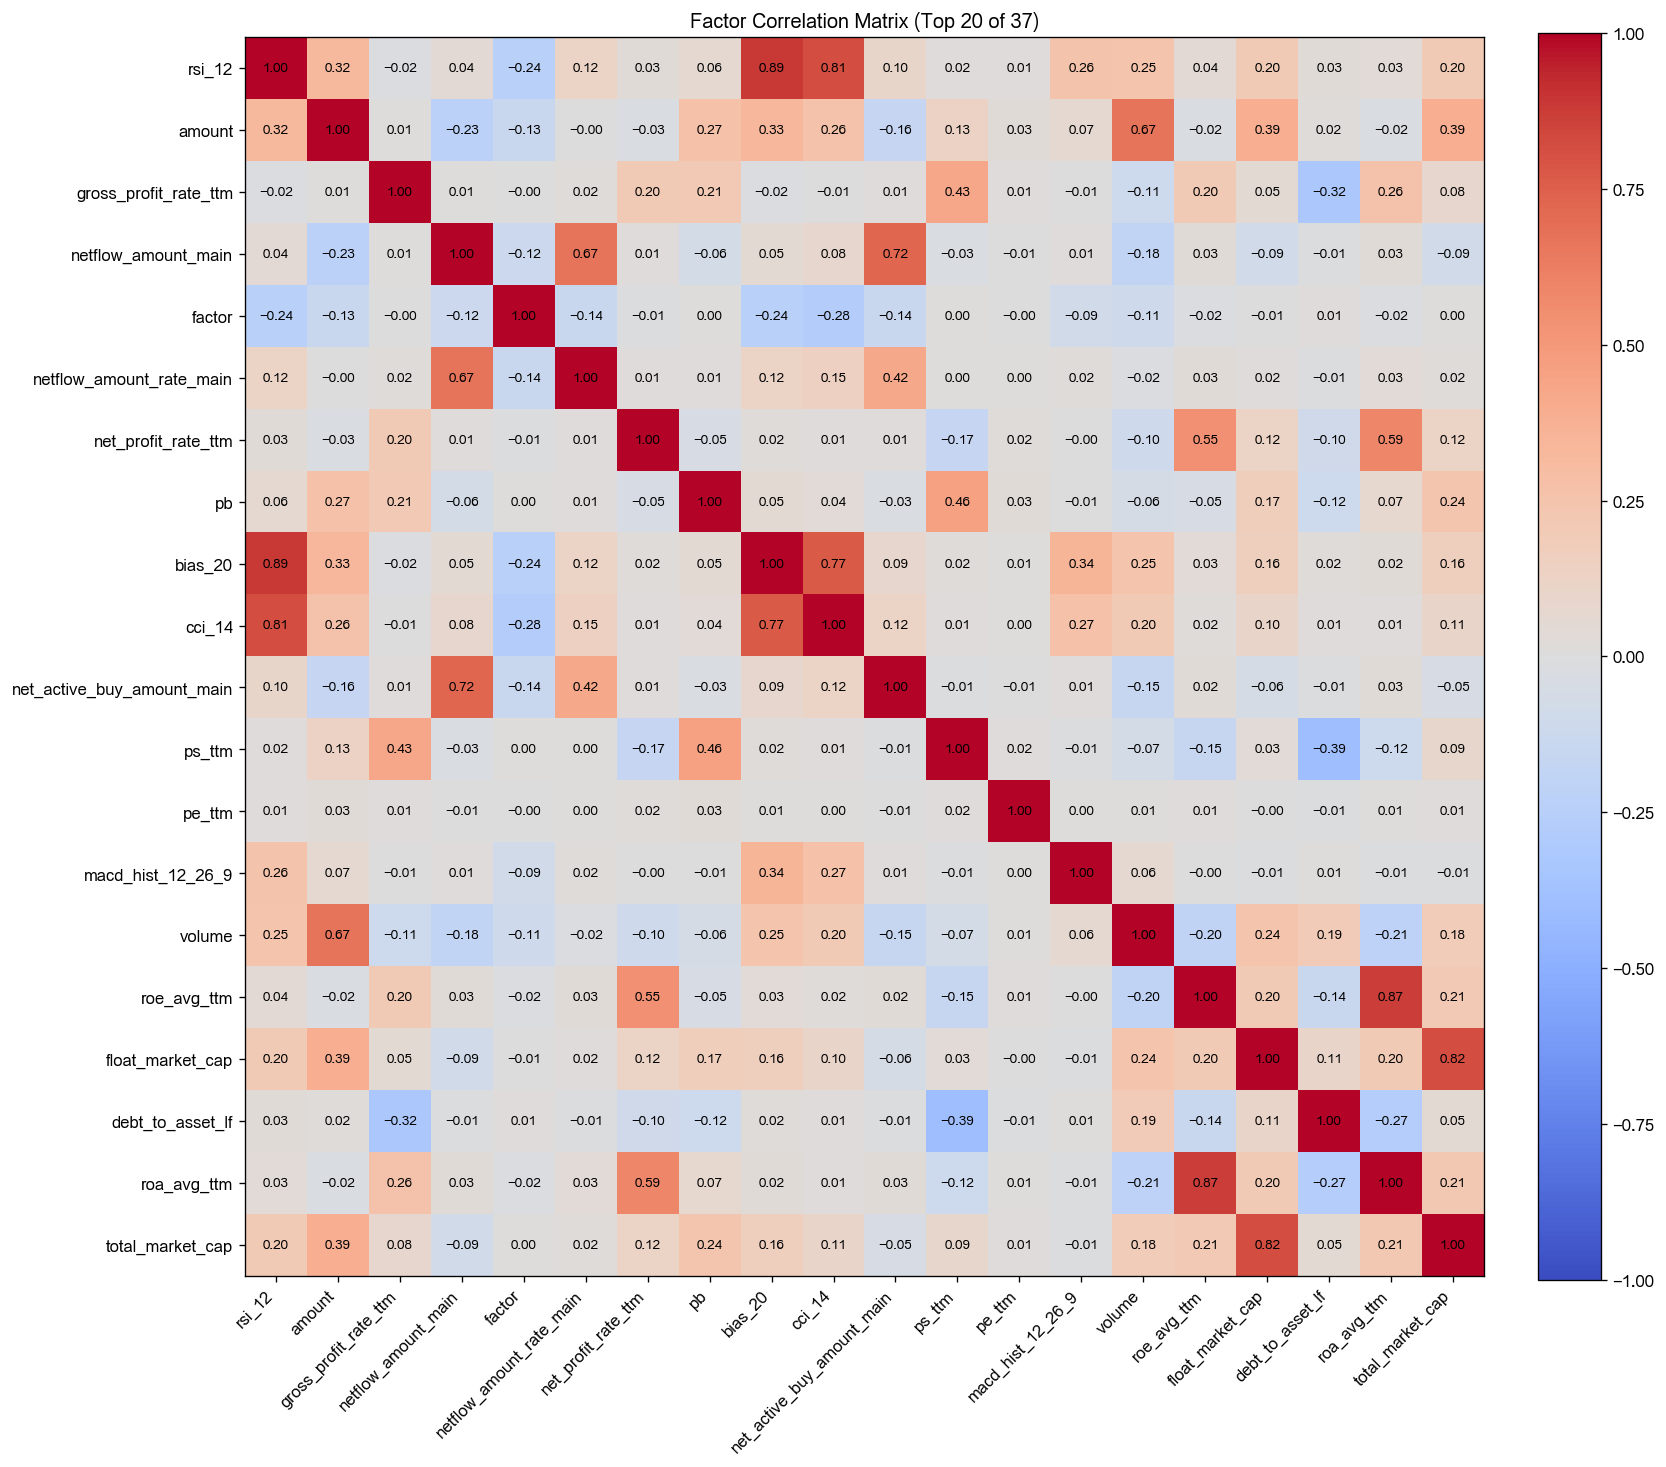

[2026-08-04 05:53:14] [warning  ] 返回的Outputs实例(size=35324674) 大于 64K, 将不会被缓存
[2026-08-04 05:53:14] [info     ] bigalpha_eval.v4 运行完成 [19.084s].


In [1]:
import dai


def main(datasources, start_date, end_date, mode='predict', model_path='fama_dynamic17_plus.json'):
    """17-signal Fama score with a bounded neural context calibration layer."""
    import json
    from pathlib import Path

    import numpy as np
    import pandas as pd

    signal_cols = [
        'direction', 'uptrend_ma10_gap_score', 'uptrend_extension_score',
        'uptrend_pullback_score', 'uptrend_ma5up_instability_score',
        'uptrend_ma5up_high_close_score', 'uptrend_ma5up_low_volume_score',
        'uptrend_ma5down_low_volume_score', 'downtrend_ma5down_low_close_score',
        'downtrend_low_rsi10_score', 'downtrend_ma5up_m10_down_score',
        'uptrend_ma5up_imbalance_score', 'downtrend_ma5down_sell_pressure_score',
        'downtrend_ma5up_imbalance_score', 'uptrend_ma5up_volatility_score',
        'uptrend_ma5down_volatility_score', 'downtrend_ma5down_volatility_score',
    ]
    binary_cols = {'direction'}
    positive_quantile_scaled_cols = [
        'uptrend_ma5up_instability_score', 'uptrend_ma5up_high_close_score',
        'uptrend_ma5up_low_volume_score',
        'uptrend_ma5down_low_volume_score', 'downtrend_ma5down_low_close_score',
    ]
    context_cols = [
        'ma30_relative', 'ma60_relative', 'had_limit_up_prev9',
        'prev9_limit_up_price_gap',
    ]
    bar1m_table = datasources['bar1m']

    def fetch_instruments(query_start, query_end):
        universe = dai.query(
            'SELECT date, instrument FROM bigalpha_2026_instruments',
            filters={'date': [query_start, query_end]},
        ).df()
        universe['trading_day'] = pd.to_datetime(universe['date']).dt.normalize()
        return universe[['trading_day', 'instrument']].drop_duplicates()

    def fetch_bar2h(instruments, query_start, query_end):
        def book_expr(side):
            return ' + '.join(
                f'(1.0 * COALESCE({side}_volume{level}, 0) / {level})'
                for level in range(1, 6)
            )

        filters = {'instrument': instruments, 'date': [query_start, query_end]}
        sql = f"""
        SELECT
            MAX(date) AS date,
            instrument,
            ARG_MAX(adjust_factor, date) AS adjust_factor,
            ARG_MAX(pre_close, date) AS pre_close,
            ARG_MIN(open, date) AS open,
            MAX(high) AS high,
            MIN(low) AS low,
            ARG_MAX(close, date) AS close,
            SUM(volume) AS volume,
            SUM(amount) AS amount,
            AVG({book_expr('ask')}) AS ask_volume_w,
            AVG({book_expr('bid')}) AS bid_volume_w
        FROM (
            SELECT *,
                   date_trunc('day', date)::DATE AS trading_day,
                   FLOOR((ROW_NUMBER() OVER (
                       PARTITION BY instrument, date_trunc('day', date)::DATE ORDER BY date
                   ) - 1) / 120) AS bucket_id
            FROM {bar1m_table}
        )
        GROUP BY instrument, trading_day, bucket_id
        ORDER BY instrument, date
        """
        volatility_sql = f"""
        WITH bucketed AS (
            SELECT date, instrument, close,
                   date_trunc('day', date)::DATE AS trading_day,
                   FLOOR((ROW_NUMBER() OVER (
                       PARTITION BY instrument, date_trunc('day', date)::DATE ORDER BY date
                   ) - 1) / 120) AS bucket_id
            FROM {bar1m_table}
        ), lagged_close AS (
            SELECT date, instrument, trading_day, bucket_id, close,
                   LAG(close) OVER (
                       PARTITION BY instrument, trading_day, bucket_id ORDER BY date
                   ) AS prev_close
            FROM bucketed
        )
        SELECT MAX(date) AS date, instrument,
               SQRT(SUM(CASE WHEN close > 0 AND prev_close > 0
                    THEN LN(close / prev_close) * LN(close / prev_close) END)) AS realized_vol_2h
        FROM lagged_close
        GROUP BY instrument, trading_day, bucket_id
        ORDER BY instrument, date
        """
        bars = dai.query(sql, filters=filters).df()
        vols = dai.query(volatility_sql, filters=filters).df()
        if bars.empty:
            return bars
        bars['date'] = pd.to_datetime(bars['date'])
        for col in [c for c in bars.columns if c not in {'date', 'instrument'}]:
            bars[col] = pd.to_numeric(bars[col], errors='coerce')
        if vols.empty:
            bars['realized_vol_2h'] = np.nan
        else:
            vols['date'] = pd.to_datetime(vols['date'])
            vols['realized_vol_2h'] = pd.to_numeric(vols['realized_vol_2h'], errors='coerce')
            bars = bars.merge(
                vols[['date', 'instrument', 'realized_vol_2h']], how='left',
                on=['date', 'instrument'], validate='one_to_one',
            )
        bars = bars.replace([np.inf, -np.inf], np.nan).sort_values(['instrument', 'date'])
        bars['trading_day'] = bars['date'].dt.normalize()
        daily = bars.sort_values(['instrument', 'date']).groupby(
            ['instrument', 'trading_day'], as_index=False
        ).tail(1)[['instrument', 'trading_day', 'pre_close', 'close', 'adjust_factor']].copy()
        daily = add_limit_up_context(daily)
        bars = bars.merge(
            daily[['instrument', 'trading_day', 'had_limit_up_prev9', 'prev9_limit_up_price_gap']],
            how='left', on=['instrument', 'trading_day'], validate='many_to_one',
        )
        bars[['open', 'high', 'low', 'close']] = bars[
            ['open', 'high', 'low', 'close']
        ].multiply(bars['adjust_factor'], axis='index')
        adjusted_daily = bars.sort_values(['instrument', 'date']).groupby(
            ['instrument', 'trading_day'], as_index=False
        ).tail(1)[['instrument', 'trading_day', 'close']].copy()
        for window, column in ((30, 'ma30_relative'), (60, 'ma60_relative')):
            reference = adjusted_daily.groupby('instrument', sort=False)['close'].transform(
                lambda value: value.rolling(window, min_periods=window).mean()
            )
            adjusted_daily[column] = adjusted_daily['close'] / reference - 1.0
        bars = bars.merge(
            adjusted_daily[['instrument', 'trading_day', 'ma30_relative', 'ma60_relative']],
            how='left', on=['instrument', 'trading_day'], validate='many_to_one',
        )
        bars['imbalance_2h'] = (
            (bars['bid_volume_w'] - bars['ask_volume_w'])
            / (bars['bid_volume_w'] + bars['ask_volume_w'])
        )
        return bars

    def add_limit_up_context(daily):
        """Raw-price limit-up state; carried price is adjusted for score features."""
        daily = daily.sort_values(['instrument', 'trading_day']).copy()
        code = daily['instrument'].str.split('.', n=1).str[0]
        exchange = daily['instrument'].str.rsplit('.', n=1).str[-1]
        limit_bps = np.full(len(daily), 1000, dtype=np.int64)
        growth = code.str.startswith(('300', '301')) & (daily['trading_day'] >= pd.Timestamp('2020-08-24'))
        limit_bps[growth.to_numpy()] = 2000
        limit_bps[code.str.startswith(('688', '689')).to_numpy()] = 2000
        limit_bps[exchange.eq('BJ').to_numpy()] = 3000
        pre_cents = np.rint(daily['pre_close'].fillna(0).to_numpy() * 100).astype(np.int64)
        close_cents = np.rint(daily['close'].fillna(0).to_numpy() * 100).astype(np.int64)
        ceiling = np.maximum((pre_cents * (10_000 + limit_bps) + 5_000) // 10_000, pre_cents + 1)
        daily['is_limit_up_close'] = daily['pre_close'].gt(0) & daily['close'].gt(0) & (close_cents == ceiling)
        daily['_bar_number'] = daily.groupby('instrument', sort=False).cumcount()
        daily['_limit_bar'] = daily['_bar_number'].where(daily['is_limit_up_close'])
        daily['_limit_close'] = (daily['close'] * daily['adjust_factor']).where(daily['is_limit_up_close'])
        prior_bar = daily.groupby('instrument', sort=False)['_limit_bar'].transform(lambda value: value.shift(1).ffill())
        prior_close = daily.groupby('instrument', sort=False)['_limit_close'].transform(lambda value: value.shift(1).ffill())
        daily['had_limit_up_prev9'] = daily.groupby('instrument', sort=False)['is_limit_up_close'].transform(
            lambda value: value.shift(1).rolling(9, min_periods=1).max()
        ).fillna(False).astype(float)
        valid_prior = (daily['_bar_number'] - prior_bar).le(9)
        previous_limit_close = prior_close.where(valid_prior, np.inf)
        daily['prev9_limit_up_price_gap'] = daily['close'] * daily['adjust_factor'] - previous_limit_close
        return daily

    def linear_regression(ys):
        xs = np.arange(len(ys), dtype=float)
        centered_x = xs - xs.mean()
        mean_y = ys.mean()
        slope = np.dot(centered_x, ys - mean_y) / np.dot(centered_x, centered_x)
        intercept = mean_y - slope * xs.mean()
        fitted = intercept + slope * xs
        ss_tot = np.square(ys - mean_y).sum()
        r_squared = 1.0 if ss_tot == 0 else 1.0 - np.square(ys - fitted).sum() / ss_tot
        r_squared = np.clip(r_squared, 1e-6, 1.0)
        trend_move = slope * (len(ys) - 1)
        deviation = (ys[-1] - fitted[-1]) / trend_move if trend_move != 0 else 0.0
        return slope, 1.0 / r_squared, deviation

    def soft_clip(value, threshold):
        magnitude = abs(value)
        return value if magnitude <= threshold else np.sign(value) * (threshold + np.log1p(magnitude - threshold))

    def calc_stock_factor(stock_df, window=20):
        stock_df = stock_df.sort_values('date').reset_index(drop=True)
        if len(stock_df) <= window:
            return pd.DataFrame()
        close = stock_df['close'].to_numpy(float)
        high = stock_df['high'].to_numpy(float)
        low = stock_df['low'].to_numpy(float)
        volume = stock_df['volume'].to_numpy(float)
        rows = []
        for i in range(window, len(stock_df)):
            slope, instability, deviation = linear_regression(close[i - window + 1:i + 1])
            direction = float(np.sign(slope))
            g20_up = float(slope > 0)
            g20_down = float(slope < 0)
            ma5_prev = np.mean(close[i - 5:i])
            g5_up = float(close[i] >= ma5_prev)
            g5_down = float(close[i] < ma5_prev)
            volume_base = np.nanmean(volume[i - window:i])
            relative_volume = volume[i] / volume_base - 1.0 if volume_base > 0 else np.nan
            high_volume = np.clip(relative_volume, 0.0, 1.0)
            low_volume = np.clip(-relative_volume, 0.0, 1.0)
            ma10 = np.mean(close[i - 9:i + 1])
            ma10_gap = (ma10 - close[i]) / ma10 if ma10 != 0 else np.nan
            m10 = np.log(close[i] / close[i - 10])
            clipped_deviation = soft_clip(deviation, 5.0)
            clipped_instability = soft_clip(instability, 10.0)
            bar_range = high[i] - low[i]
            high_close = (close[i] - low[i]) / bar_range if bar_range > 1e-12 else 0.0
            low_close = (high[i] - close[i]) / bar_range if bar_range > 1e-12 else 0.0
            rsi_delta = np.diff(close[i - 10:i + 1])
            rsi_gain = np.mean(np.clip(rsi_delta, 0.0, None))
            rsi_loss = np.mean(np.clip(-rsi_delta, 0.0, None))
            rsi10 = 100.0 * rsi_gain / (rsi_gain + rsi_loss + 1e-12)
            rows.append((
                stock_df.at[i, 'date'], stock_df.at[i, 'instrument'], direction,
                g20_up * ma10_gap,
                g20_up * max(clipped_deviation, 0.0),
                g20_up * max(-clipped_deviation, 0.0),
                g20_up * g5_up * clipped_instability,
                g20_up * g5_up * high_close,
                g20_up * g5_up * low_volume,
                g20_up * g5_down * low_volume,
                g20_down * g5_down * low_close,
                g20_down * min((rsi10 - 40.0) / 40.0, 0.0),
                g20_down * g5_up * min(m10, 0.0),
                g20_up * g5_up * stock_df.at[i, 'imbalance_2h'],
                g20_down * g5_down * min(stock_df.at[i, 'imbalance_2h'], 0.0),
                g20_down * g5_up * stock_df.at[i, 'imbalance_2h'],
                g20_up * g5_up * max(stock_df.at[i, 'realized_vol_2h'], 0.0),
                g20_up * g5_down * max(stock_df.at[i, 'realized_vol_2h'], 0.0),
                g20_down * g5_down * max(stock_df.at[i, 'realized_vol_2h'], 0.0),
            ))
        return pd.DataFrame(rows, columns=['date', 'instrument', *signal_cols])

    def build_feature_sample(bar2h):
        pieces = [
            result for _, stock_df in bar2h.groupby('instrument', sort=False)
            if not (result := calc_stock_factor(stock_df)).empty
        ]
        if not pieces:
            return pd.DataFrame()
        features = pd.concat(pieces, ignore_index=True)
        features['trading_day'] = pd.to_datetime(features['date']).dt.normalize()
        features = (
            features.sort_values('date')
            .groupby(['instrument', 'trading_day'], as_index=False)
            .tail(1)
        )
        daily_context = bar2h.sort_values(['instrument', 'date']).groupby(
            ['instrument', 'trading_day'], as_index=False
        ).tail(1)[['date', 'instrument', *context_cols]]
        return features.merge(daily_context, how='left', on=['date', 'instrument'], validate='one_to_one')

    def standardize(day_df):
        x = day_df[signal_cols].astype(float).copy()
        for col in positive_quantile_scaled_cols:
            mask = x[col] > 0
            q95 = x.loc[mask, col].quantile(0.95)
            x[col] = 0.0
            if np.isfinite(q95) and q95 > 0:
                x.loc[mask, col] = (day_df.loc[mask, col] / q95).clip(0.0, 1.0)
        for col in signal_cols:
            if col in binary_cols or col in positive_quantile_scaled_cols:
                continue
            std = x[col].std(ddof=0)
            x[col] = 0.0 if not np.isfinite(std) or std == 0 else (x[col] - x[col].mean()) / std
        return x

    def zscore(value):
        std = value.std(ddof=0)
        return pd.Series(0.0, index=value.index) if not np.isfinite(std) or std == 0 else (value - value.mean()) / std

    def load_model():
        with Path(model_path).open(encoding='utf-8') as handle:
            model = json.load(handle)
        if model.get('feature_cols') != signal_cols or model.get('context_cols') != context_cols:
            raise ValueError('model feature/context columns do not match fama_dynamic17_plus')
        if model.get('adjustment_mode') != 'bounded_tanh':
            raise ValueError('expected bounded tanh dynamic calibration model')
        return model

    def predict(model, features):
        features = features.copy()
        valid = features[[*signal_cols, 'ma30_relative', 'ma60_relative']].replace([np.inf, -np.inf], np.nan).notna().all(axis=1)
        features['factor'] = np.nan
        for _, day_df in features.loc[valid].groupby('trading_day', sort=False):
            context = np.column_stack([
                zscore(day_df['ma30_relative']), zscore(day_df['ma60_relative']),
                day_df['had_limit_up_prev9'].fillna(0.0),
                zscore(day_df['prev9_limit_up_price_gap'].replace([np.inf, -np.inf], np.nan)).fillna(0.0),
            ])
            dynamic_matrix = np.asarray(model['dynamic_matrix'], dtype=float)
            adjustment = model['adjustment_cap'] * np.tanh(context @ dynamic_matrix.T)
            beta = np.asarray(model['static_beta'], dtype=float)
            x = standardize(day_df).to_numpy(dtype=float)
            features.loc[day_df.index, 'factor'] = model['static_intercept'] + (x * beta * (1.0 + adjustment)).sum(axis=1)
        return features

    if mode == 'train':
        return pd.DataFrame(columns=['date', 'instrument', 'factor'])
    if mode != 'predict':
        raise ValueError("mode must be 'train' or 'predict'")

    universe = fetch_instruments(start_date, end_date)
    instruments = sorted(universe['instrument'].unique())
    # 60 trading-day context plus a conservative calendar buffer.  The
    # platform provides a historical buffer before the requested score range.
    history_start = (pd.to_datetime(start_date) - pd.Timedelta(days=120)).strftime('%Y-%m-%d %H:%M:%S')
    features = build_feature_sample(fetch_bar2h(instruments, history_start, end_date))
    if features.empty:
        return pd.DataFrame(columns=['date', 'instrument', 'factor'])
    result = predict(load_model(), features)[['trading_day', 'instrument', 'factor']]
    result = result.loc[result['trading_day'].between(pd.to_datetime(start_date), pd.to_datetime(end_date))]
    result = result.merge(universe, how='inner', on=['trading_day', 'instrument'])
    if result['factor'].isna().any() or not np.isfinite(result['factor']).all():
        raise ValueError('generated factor contains missing or infinite values')
    # Submission score only: positive scalar scaling preserves the daily ranking.
    result['factor'] = result['factor'] * 10.0
    result['date'] = result['trading_day']
    return result[['date', 'instrument', 'factor']].sort_values(['date', 'instrument']).reset_index(drop=True)


if __name__ == '__main__':
    from bigmodule import M
    import pandas as pd

    datasources = {'bar1m': 'bigalpha_2026_stock_bar1m', 'financial': 'bigalpha_2026_financial'}
    start_date, end_date = '2024-01-01 00:00:00', '2024-12-31 23:59:59'
    factor_data = main(datasources, start_date, end_date, 'predict', 'fama_dynamic17_plus.json')
    if factor_data.empty:
        raise ValueError('factor_data is empty')
    factor_pool = dai.query(
        'SELECT * FROM bigalpha_2026_factorlib', filters={'date': [start_date, end_date]}
    ).df()
    factor_data['date'] = pd.to_datetime(factor_data['date'])
    factor_pool['date'] = pd.to_datetime(factor_pool['date'])
    M.bigalpha_eval._latest(
        factor_data=factor_data, factor_pool=factor_pool, process_pools=False, show=True,
    )
